In [1]:
import torch
import torch.nn as nn
from torch.optim import AdamW,Adam
import pandas as pd
import numpy as np
from torch.utils.data import TensorDataset, DataLoader
import pickle
import matplotlib.pyplot as plt

In [2]:
# Use GPU if it is avaialable
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


In [3]:
df = pd.read_csv("Climate_data.csv")

data = df.drop("Date Time" , axis=1)
column_label = data.columns.tolist()
data = torch.tensor(data.values , dtype=torch.float32)

mean = data.mean(dim=0)
std = data.std(dim=0)

data = (data - mean)/std

In [5]:
data = data[:len(data)-(len(data)%6)]
data = data.float().reshape(6,data.shape[0]//6,*data.shape[1:]).mean(dim=0)

In [24]:
data_X = []
data_y = []

for i in range(0 , len(data)-(72*10)-1 , 10):
    data_X.append(data[i:i+(72*10)])
    data_y.append(data[i+(72*10)])
data_X = torch.stack(data_X)
data_y = torch.stack(data_y)

In [26]:
training_time = int(0.8 * len(data_X))

train_x = data_X[:training_time]
train_y = data_y[:training_time]
test_x = data_X[training_time:]
test_y = data_y[training_time:]

In [28]:
dataset = TensorDataset(train_x , train_y)
loader = DataLoader(dataset , batch_size=100 , shuffle=False)

In [15]:
class Encoder_Layer(nn.Module):
    def __init__(self , hidden_dim , num_heads):
        super().__init__()
        self.hidden_dim = hidden_dim 
        self.num_heads = num_heads
        self.head_dim = hidden_dim//num_heads

        # For Query Key and Values
        self.query = nn.Linear(in_features=hidden_dim , out_features=hidden_dim , bias=False)
        self.key = nn.Linear(in_features=hidden_dim , out_features=hidden_dim , bias=False)
        self.value = nn.Linear(in_features=hidden_dim , out_features=hidden_dim , bias=False)

        # Attention combining all the other attentions
        self.attention = nn.Linear(in_features=hidden_dim , out_features=hidden_dim)

        # Layer Normalisation
        self.layer_norm_1 = nn.LayerNorm(hidden_dim)
        self.layer_norm_2 = nn.LayerNorm(hidden_dim)

        # Feed Forward Network ffn
        self.ffn = nn.Sequential(
            nn.Linear(in_features=hidden_dim , out_features=hidden_dim*4),
            nn.ReLU(),
            nn.Linear(in_features=hidden_dim*4 , out_features=hidden_dim)
        )


    def forward(self , x):
        batch_size = x.shape[0]
        seq_len = x.shape[1]
        embedding = x

        # Querry , Key and Values
        Q = self.query(embedding)
        K = self.key(embedding)
        V = self.value(embedding)
        Q = Q.reshape(batch_size , seq_len , self.num_heads , self.head_dim).transpose(1,2)
        K = K.reshape(batch_size , seq_len , self.num_heads , self.head_dim).transpose(1,2)
        V = V.reshape(batch_size , seq_len , self.num_heads , self.head_dim).transpose(1,2)
        
        # Total Attention
        score = Q @ K.transpose(-2,-1)
        attention = torch.softmax(score/(self.head_dim**0.5) , dim=-1) @ V        
        attention = attention.transpose(1,2)
        attention = attention.reshape(batch_size , seq_len , self.hidden_dim)
        attention = self.attention(attention)

        # Feed Forward network and layer norm
        embedding = embedding + attention
        embedding = self.layer_norm_1(embedding)
        ffn_out = self.ffn(embedding)
        embedding = embedding + ffn_out
        embedding = self.layer_norm_2(embedding)

        # Returning the contextualised embeddings
        return embedding
    


class Encoder(nn.Module):
    def __init__(self , hidden_dim , num_heads):
        super().__init__()
        self.hidden_dim = hidden_dim
        
        seq_len = 720
        N = 10000
        position = torch.arange(seq_len).unsqueeze(1)      # (720,1)
        i = torch.arange(self.hidden_dim // 2)             # (32,)        
        div_term = N ** (-2 * i / self.hidden_dim)         # (32,)    
        positional_encoding = torch.zeros(seq_len, self.hidden_dim)
        positional_encoding[:, 0::2] = torch.sin(position * div_term)
        positional_encoding[:, 1::2] = torch.cos(position * div_term)
        self.positional_encoding = positional_encoding.to(device)
        
        # Initially Convert the given vector into hidden dimension
        self.initial_embedding = nn.Linear(in_features=14 , out_features=hidden_dim)

        # Encoding layer
        self.layer_1 = Encoder_Layer(hidden_dim , num_heads)
        self.layer_2 = Encoder_Layer(hidden_dim , num_heads)

        # FInal Predictor
        self.final = nn.Linear(in_features=hidden_dim , out_features=14)

    def forward(self , x):
        x = x.to(device)

        # Initial Embedding 
        embedding = self.initial_embedding(x)

        # Positional Encoding
        embedding = embedding + self.positional_encoding

        # Passing through embedding layers
        embedding = self.layer_1(embedding)
        embedding = self.layer_2(embedding)

        # Use last time as it has all the context from previous one also to predict next day weather
        y_pred = self.final(embedding[: , -1 , :])

        return y_pred

In [31]:
torch.manual_seed(12)
Model = Encoder(64 , 2).to(device)
optimiser = AdamW(Model.parameters() , lr=1e-4 , weight_decay=1e-3 , )
loss_fn = nn.MSELoss()

epochs = 10
losses = []

for epoch in range(epochs):
    running_loss = 0
    batch = 0
    for x , y in loader:
        batch = batch+1
        y_pred = Model(x)
        loss = loss_fn(y_pred , y.to(device))
        optimiser.zero_grad()
        loss.backward()
        optimiser.step()
        running_loss = running_loss + loss.item()
        print(f"Epoch : {epoch+1}\tBatch : {batch}/{len(loader)}\tLoss : {loss.item()}")
    losses.append(running_loss/len(loader))
    print(f"----------Epoch : {epoch+1}\tAverage Loss in epoch : {running_loss/len(loader)}----------\n")

Epoch : 1	Batch : 1/56	Loss : 0.40087762475013733
Epoch : 1	Batch : 2/56	Loss : 0.40645164251327515
Epoch : 1	Batch : 3/56	Loss : 0.4235321879386902
Epoch : 1	Batch : 4/56	Loss : 0.29214155673980713
Epoch : 1	Batch : 5/56	Loss : 0.47080469131469727
Epoch : 1	Batch : 6/56	Loss : 0.4304928183555603
Epoch : 1	Batch : 7/56	Loss : 0.34252992272377014
Epoch : 1	Batch : 8/56	Loss : 0.2231082171201706
Epoch : 1	Batch : 9/56	Loss : 0.24133335053920746
Epoch : 1	Batch : 10/56	Loss : 0.2752548158168793
Epoch : 1	Batch : 11/56	Loss : 0.2771182954311371
Epoch : 1	Batch : 12/56	Loss : 0.25595614314079285
Epoch : 1	Batch : 13/56	Loss : 0.18840357661247253
Epoch : 1	Batch : 14/56	Loss : 0.17010822892189026
Epoch : 1	Batch : 15/56	Loss : 0.187407448887825
Epoch : 1	Batch : 16/56	Loss : 0.19079144299030304
Epoch : 1	Batch : 17/56	Loss : 0.1331252157688141
Epoch : 1	Batch : 18/56	Loss : 0.10629919916391373
Epoch : 1	Batch : 19/56	Loss : 0.10251778364181519
Epoch : 1	Batch : 20/56	Loss : 0.086321182548999

In [32]:
# Saving model weights
weights = Model.state_dict()
with open("Transformer_model_weights.pkl","wb") as F:
    pickle.dump(weights , F)

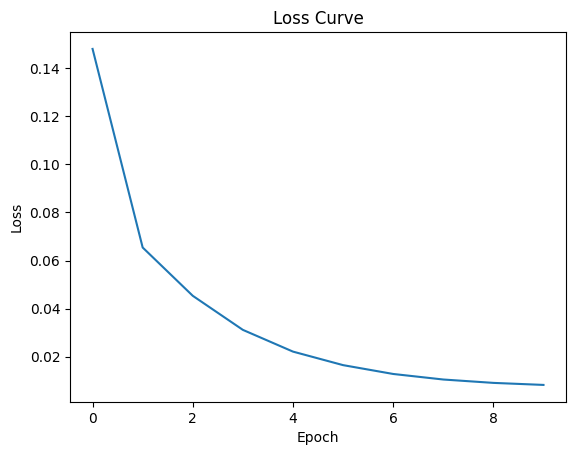

In [33]:
plt.plot(losses)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss Curve")
plt.show()

In [44]:
with torch.no_grad():
    y_pred = Model(test_x[:100])
    y_pred = y_pred.cpu()
    df1 = pd.DataFrame((test_y[:100]*std + mean).numpy())
    df2 = pd.DataFrame((y_pred*std + mean).numpy())
    df1.columns = column_label
    df2.columns = column_label
    mse = nn.MSELoss()(y_pred , test_y[:100])
    mae = nn.L1Loss()(y_pred , test_y[:100])
    huber = nn.HuberLoss()(y_pred , test_y[:100])

In [45]:
print(f"MSE Loss : {mse}")
print(f"MAE Loss : {mae}")
print(f"Huber Loss : {huber}")

MSE Loss : 0.005940868053585291
MAE Loss : 0.04671803489327431
Huber Loss : 0.0029704340267926455


In [43]:
(df1-df2).max() - (df1-df2).min()

p (mbar)             2.015869
T (degC)             1.658208
Tpot (K)             1.919098
Tdew (degC)          1.559788
rh (%)               6.504135
VPmax (mbar)         1.837786
VPact (mbar)         0.836354
VPdef (mbar)         1.568531
sh (g/kg)            0.413960
H2OC (mmol/mol)      0.573930
rho (g/m**3)        14.196167
wv (m/s)             7.124543
max. wv (m/s)        6.066896
wd (deg)           115.695587
dtype: float32

In [53]:
df1.tail()

,p (mbar),T (degC),Tpot (K),Tdew (degC),rh (%),VPmax (mbar),VPact (mbar),VPdef (mbar),sh (g/kg),H2OC (mmol/mol),rho (g/m**3),wv (m/s),max. wv (m/s),wd (deg)
95,989.010010,10.168333,284.214996,3.976667,68.753334,14.430000,9.045000,5.385000,5.708333,9.140000,1212.991699,1.998333,3.628333,155.736664
96,989.231689,9.830000,283.855011,4.026667,71.486671,14.035000,8.893333,5.141666,5.608333,8.981667,1214.731689,1.923333,3.551667,177.665009
97,989.750000,9.045000,283.026672,3.791667,72.778336,13.296667,8.793333,4.505000,5.543333,8.876667,1218.811646,1.935000,3.045000,216.451660
98,990.281677,8.486667,282.424988,3.116667,71.548332,12.816667,8.493334,4.323333,5.351666,8.568334,1222.046631,1.705000,2.928334,194.991669
99,990.606689,8.485001,282.401672,3.511667,72.235001,12.495001,8.708333,3.786667,5.485000,8.781667,1222.175049,1.426667,2.243333,113.671677


In [52]:
df2.tail()

,p (mbar),T (degC),Tpot (K),Tdew (degC),rh (%),VPmax (mbar),VPact (mbar),VPdef (mbar),sh (g/kg),H2OC (mmol/mol),rho (g/m**3),wv (m/s),max. wv (m/s),wd (deg)
95,988.519043,10.333128,284.333191,3.881306,68.907410,14.461883,8.851917,5.756293,5.549998,9.071142,1214.130859,0.608603,2.021445,190.857727
96,988.708740,9.935926,284.000153,4.113525,70.841209,13.994064,8.809642,5.393957,5.540962,9.052092,1215.986572,1.079461,2.056700,189.553864
97,989.341492,9.112991,283.022858,3.621240,73.112335,13.147665,8.541277,4.848904,5.528706,8.886649,1220.463989,0.722999,2.015743,147.598480
98,989.640747,8.619797,282.739716,3.266498,71.882065,12.982092,8.407462,4.607150,5.231506,8.564734,1221.735840,0.736985,1.413148,213.957550
99,990.219849,8.554455,282.238953,3.110916,74.141808,12.540386,8.358461,4.326325,5.427907,8.750598,1224.149780,0.060164,0.920850,138.801544


In [ ]:
# 1 - Main Query ko hidden dimension ka bana ke reshape kar do faster rahega    --DONE
# 2 - ye ek encoder layer hai jo stack karni hai isiliye alag se me embedding karao intial aur fir isme input daalo
# 3 - Positional encoding bhi sirf ek hi baar judegi so use bhi dusre wale me rakh dena
# 4 - mean pooling try karo dekho kaunsa acha hai